# OpenEvolve Baseline Analysis
## Circle Packing — GPT-5.4-mini × 10 seeds

This notebook analyzes 10 parallel runs of the OpenEvolve baseline on the circle packing problem (n=26, target sum_radii=2.635) using `gpt-5.4-mini` with different random seeds.

In [100]:
import json
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

BASE_DIR = Path('baseline_runs')
TARGET = 2.635
NUM_RUNS = 10

In [101]:
def parse_log(log_path):
    """Parse an OpenEvolve log file and extract per-iteration data."""
    iterations = []
    best_events = []
    errors = []
    best_score = 0.0
    
    with open(log_path) as f:
        for line in f:
            # Parse completed iterations
            iter_match = re.search(
                r'Iteration (\d+):.*completed in ([\d.]+)s', line
            )
            if iter_match:
                it = int(iter_match.group(1))
                duration = float(iter_match.group(2))
                iterations.append({'iteration': it, 'duration': duration})
            
            # Parse evaluation results — direct field extraction
            if 'Evaluated program' in line:
                score_match = re.search(r'combined_score=([\d.]+)', line)
                sr_match = re.search(r'sum_radii=([\d.]+)', line)
                val_match = re.search(r'validity=([\d.]+)', line)
                et_match = re.search(r'eval_time=([\d.]+)', line)
                
                if iterations and score_match:
                    score = float(score_match.group(1))
                    iterations[-1].update({
                        'combined_score': score,
                        'sum_radii': float(sr_match.group(1)) if sr_match else 0,
                        'validity': float(val_match.group(1)) if val_match else 0,
                        'eval_time': float(et_match.group(1)) if et_match else 0,
                    })
            
            # Parse best program events
            best_match = re.search(
                r'New best program.*combined_score: ([\d.]+) . ([\d.]+)', line
            )
            if best_match:
                old_score = float(best_match.group(1))
                new_score = float(best_match.group(2))
                iter_num_match = re.search(r'Iteration (\d+):', line)
                iter_num = int(iter_num_match.group(1)) if iter_num_match else len(best_events)
                best_events.append({
                    'iteration': iter_num,
                    'old_score': old_score,
                    'new_score': new_score,
                })
                best_score = new_score
            
            # Parse best events from star marker
            star_match = re.search(
                r'New best solution found at iteration (\d+)', line
            )
            if star_match:
                it = int(star_match.group(1))
                if not any(b['iteration'] == it for b in best_events):
                    best_events.append({'iteration': it})
            
            # Parse errors
            err_match = re.search(r'error=(.+?)(?:,|$)', line)
            if err_match and 'Iteration' in line:
                errors.append(err_match.group(1).strip())
    
    return {
        'iterations': iterations,
        'best_events': best_events,
        'errors': errors,
        'best_score': best_score,
    }

In [102]:
# Load all runs
runs = {}
for i in range(1, NUM_RUNS + 1):
    log_files = sorted(glob.glob(str(BASE_DIR / f'run_{i}' / 'logs' / '*.log')))
    if log_files:
        runs[i] = parse_log(log_files[-1])  # Use most recent log
        print(f"Run {i}: {len(runs[i]['iterations'])} iterations, "
              f"best={runs[i]['best_score']:.4f}, "
              f"{len(runs[i]['best_events'])} improvements, "
              f"{len(runs[i]['errors'])} errors")
    else:
        print(f"Run {i}: no log found")

Run 1: 100 iterations, best=0.8820, 16 improvements, 0 errors
Run 2: 100 iterations, best=0.9299, 7 improvements, 0 errors
Run 3: 100 iterations, best=0.8630, 10 improvements, 0 errors
Run 4: 100 iterations, best=0.8775, 19 improvements, 0 errors
Run 5: 100 iterations, best=0.7797, 10 improvements, 0 errors
Run 6: 71 iterations, best=0.8658, 8 improvements, 0 errors
Run 7: 100 iterations, best=0.8425, 6 improvements, 0 errors
Run 8: 100 iterations, best=0.9504, 13 improvements, 0 errors
Run 9: 99 iterations, best=0.9294, 8 improvements, 0 errors
Run 10: 100 iterations, best=0.8899, 17 improvements, 0 errors


## 1. Best Score Over Time (Convergence Curves)

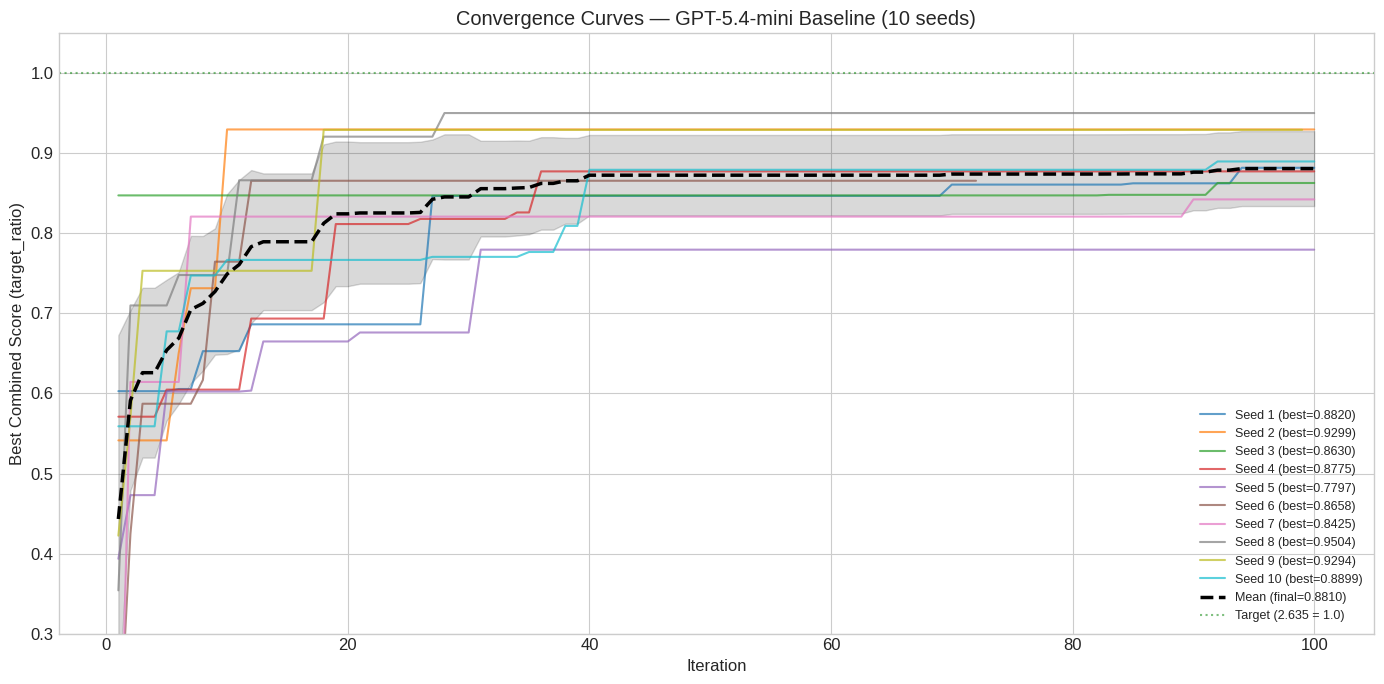

In [103]:
fig, ax = plt.subplots(figsize=(14, 7))

colors = plt.cm.tab10(np.linspace(0, 1, NUM_RUNS))

all_best_trajectories = []

for i, (run_id, data) in enumerate(sorted(runs.items())):
    # Build cumulative best score trajectory
    scores = []
    best_so_far = 0.0
    for it_data in sorted(data['iterations'], key=lambda x: x['iteration']):
        score = it_data.get('combined_score', 0.0)
        best_so_far = max(best_so_far, score)
        scores.append((it_data['iteration'], best_so_far))
    
    if scores:
        iters, vals = zip(*scores)
        ax.plot(iters, vals, color=colors[i], alpha=0.7, linewidth=1.5,
                label=f'Seed {run_id} (best={max(vals):.4f})')
        all_best_trajectories.append((list(iters), list(vals)))

# Plot mean trajectory
if all_best_trajectories:
    max_iter = max(max(t[0]) for t in all_best_trajectories)
    common_iters = range(1, int(max_iter) + 1)
    interpolated = []
    for iters, vals in all_best_trajectories:
        interp = []
        val_idx = 0
        for ci in common_iters:
            while val_idx < len(iters) - 1 and iters[val_idx + 1] <= ci:
                val_idx += 1
            if val_idx < len(vals):
                interp.append(vals[val_idx])
            else:
                interp.append(vals[-1])
        interpolated.append(interp)
    
    mean_vals = np.mean(interpolated, axis=0)
    std_vals = np.std(interpolated, axis=0)
    ax.plot(list(common_iters), mean_vals, color='black', linewidth=2.5,
            label=f'Mean (final={mean_vals[-1]:.4f})', linestyle='--')
    ax.fill_between(list(common_iters), mean_vals - std_vals, mean_vals + std_vals,
                    alpha=0.15, color='black')

ax.axhline(y=1.0, color='green', linestyle=':', alpha=0.5, label='Target (2.635 = 1.0)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best Combined Score (target_ratio)')
ax.set_title('Convergence Curves — GPT-5.4-mini Baseline (10 seeds)')
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0.3, 1.05)
plt.tight_layout()
plt.savefig('baseline_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Sum of Radii Over Time

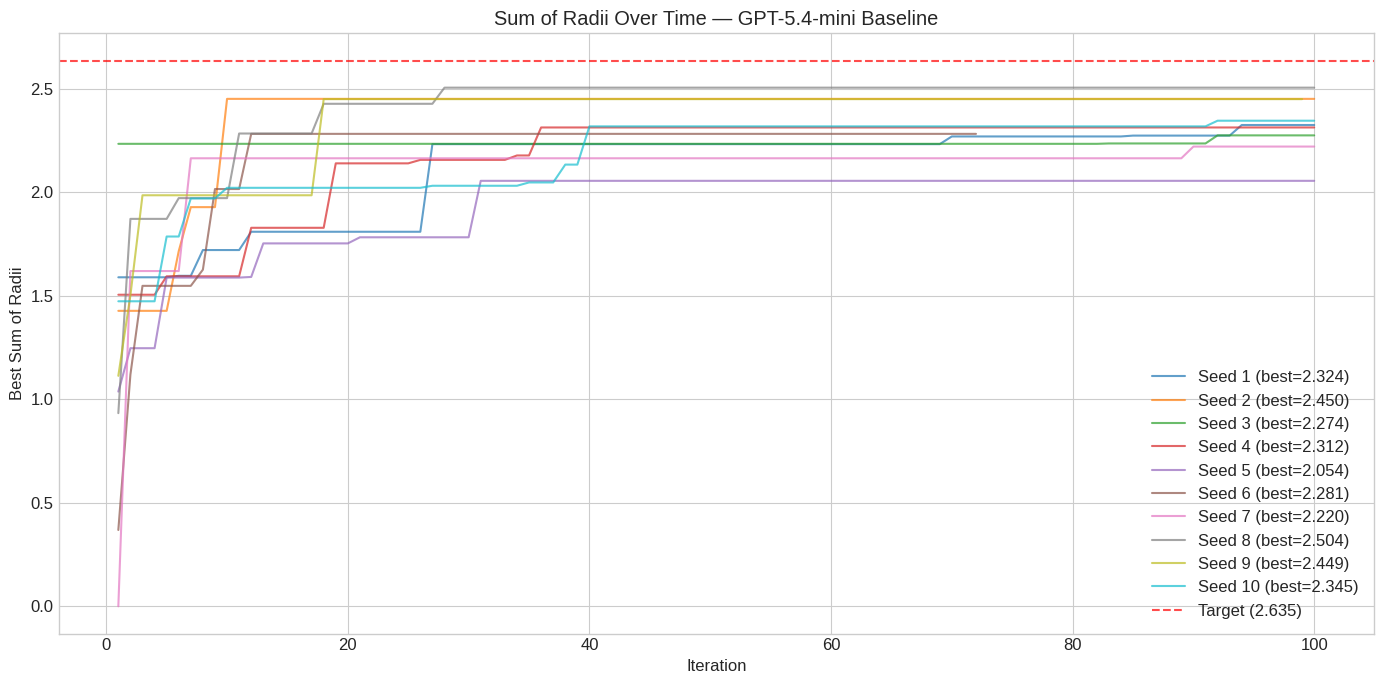

In [104]:
fig, ax = plt.subplots(figsize=(14, 7))

for i, (run_id, data) in enumerate(sorted(runs.items())):
    # Build cumulative best sum_radii trajectory
    scores = []
    best_so_far = 0.0
    for it_data in sorted(data['iterations'], key=lambda x: x['iteration']):
        sr = it_data.get('sum_radii', 0.0)
        if it_data.get('validity', 0) > 0:
            best_so_far = max(best_so_far, sr)
        scores.append((it_data['iteration'], best_so_far))
    
    if scores:
        iters, vals = zip(*scores)
        ax.plot(iters, vals, color=colors[i], alpha=0.7, linewidth=1.5,
                label=f'Seed {run_id} (best={max(vals):.3f})')

ax.axhline(y=TARGET, color='red', linestyle='--', alpha=0.7, label=f'Target ({TARGET})')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best Sum of Radii')
ax.set_title('Sum of Radii Over Time — GPT-5.4-mini Baseline')
ax.legend(loc='lower right')
plt.tight_layout()
# plt.savefig('baseline_sum_radii.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Per-Iteration Score Distribution

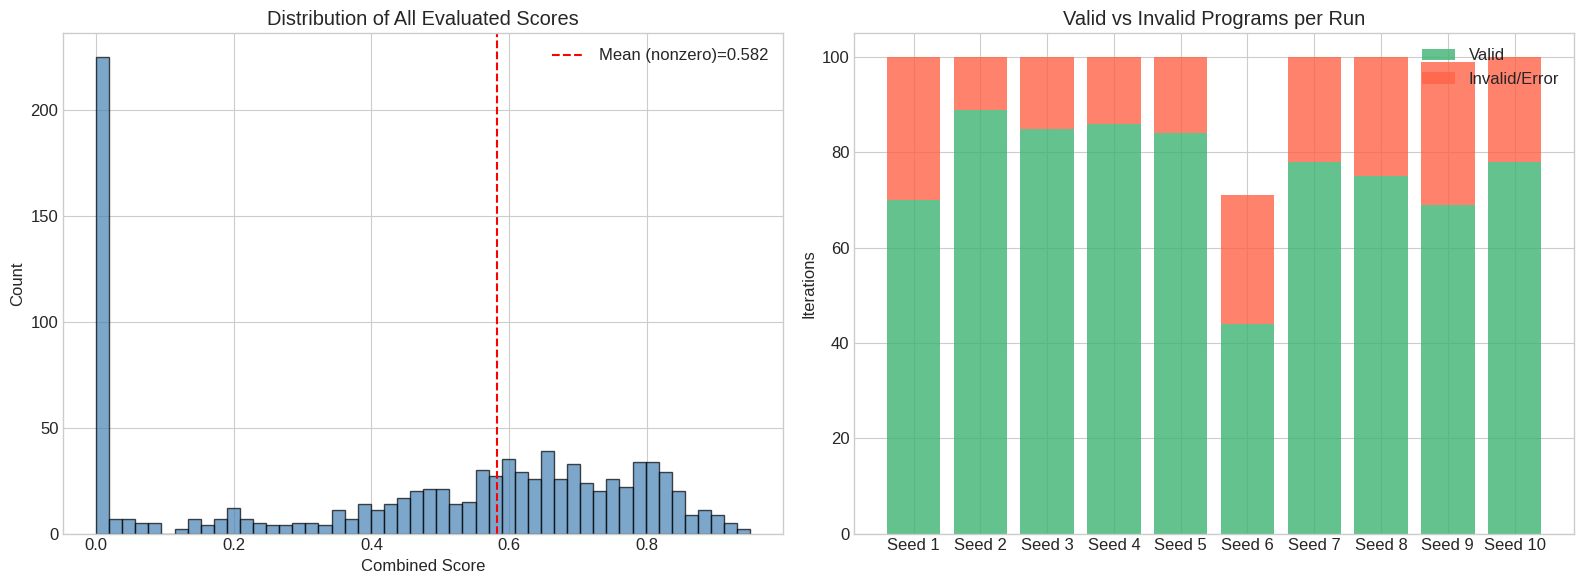

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of all scores
all_scores = []
for data in runs.values():
    for it in data['iterations']:
        s = it.get('combined_score', 0.0)
        all_scores.append(s)

axes[0].hist(all_scores, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Combined Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of All Evaluated Scores')
axes[0].axvline(x=np.mean([s for s in all_scores if s > 0]), 
                color='red', linestyle='--', label=f'Mean (nonzero)={np.mean([s for s in all_scores if s > 0]):.3f}')
axes[0].legend()

# Valid vs invalid per run
run_ids = sorted(runs.keys())
valid_counts = []
invalid_counts = []
for rid in run_ids:
    data = runs[rid]
    valid = sum(1 for it in data['iterations'] if it.get('combined_score', 0) > 0)
    invalid = len(data['iterations']) - valid
    valid_counts.append(valid)
    invalid_counts.append(invalid)

x = np.arange(len(run_ids))
axes[1].bar(x, valid_counts, label='Valid', color='mediumseagreen', alpha=0.8)
axes[1].bar(x, invalid_counts, bottom=valid_counts, label='Invalid/Error', color='tomato', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Seed {r}' for r in run_ids])
axes[1].set_ylabel('Iterations')
axes[1].set_title('Valid vs Invalid Programs per Run')
axes[1].legend()

plt.tight_layout()
# plt.savefig('baseline_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Improvement Rate (Best-Program Events Over Time)

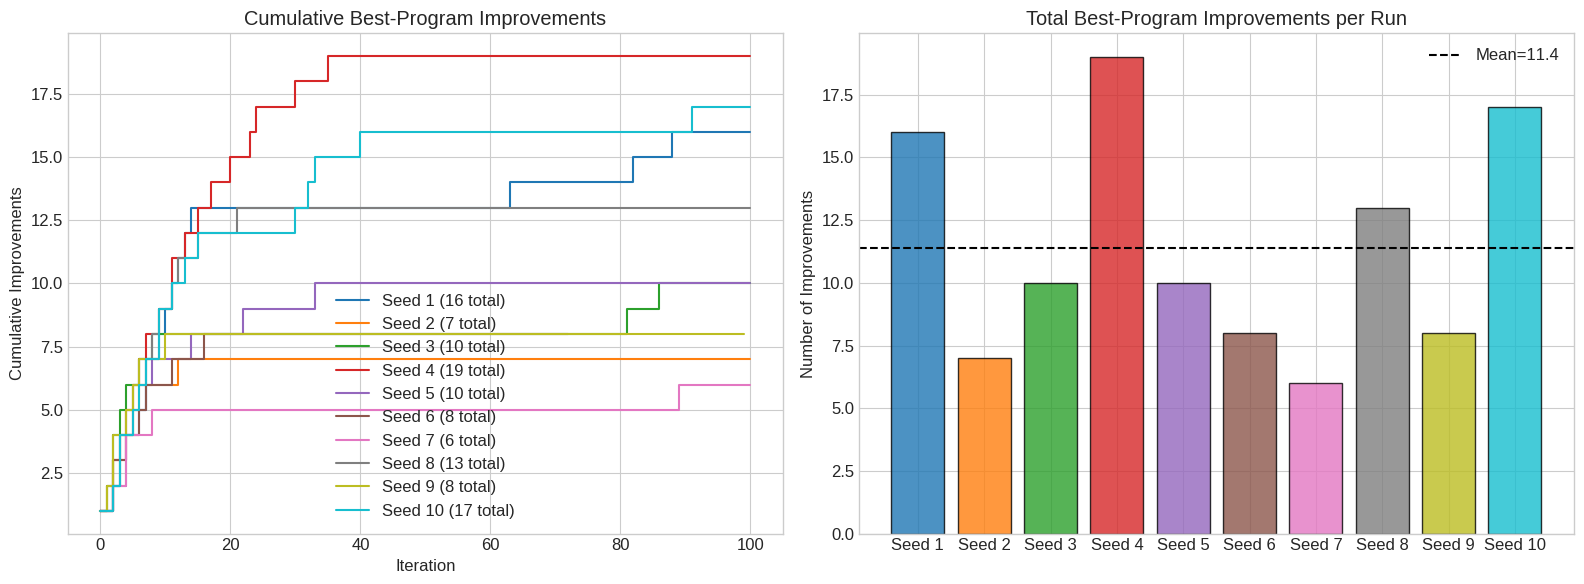

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cumulative improvements over time
for i, (run_id, data) in enumerate(sorted(runs.items())):
    events = sorted(data['best_events'], key=lambda x: x.get('iteration', 0))
    if events:
        iters = [e.get('iteration', 0) for e in events]
        cum_count = list(range(1, len(events) + 1))
        # Extend to end of run
        max_iter = max(it['iteration'] for it in data['iterations']) if data['iterations'] else 100
        iters.append(max_iter)
        cum_count.append(cum_count[-1])
        axes[0].step(iters, cum_count, color=colors[i], linewidth=1.5,
                     label=f'Seed {run_id} ({len(events)} total)', where='post')

axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cumulative Improvements')
axes[0].set_title('Cumulative Best-Program Improvements')
axes[0].legend()

# Total improvements bar chart
improvement_counts = [len(runs[r]['best_events']) for r in run_ids]
axes[1].bar([f'Seed {r}' for r in run_ids], improvement_counts, 
            color=colors[:len(run_ids)], alpha=0.8, edgecolor='black')
axes[1].set_ylabel('Number of Improvements')
axes[1].set_title('Total Best-Program Improvements per Run')
axes[1].axhline(y=np.mean(improvement_counts), color='black', linestyle='--',
                label=f'Mean={np.mean(improvement_counts):.1f}')
axes[1].legend()

plt.tight_layout()
# plt.savefig('baseline_improvements.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Error Deep Dive
Detailed breakdown of failure modes. Programs fail in three ways:
1. **Timeout/Zero score** — program ran but took >90s or produced score=0 (invalid geometry)
2. **Runtime errors** — crashes (undefined vars, index OOB, shape mismatches)
3. **Structural errors** — wrong output shape, missing functions, bad return signature

We parse errors from both explicit `error=` log entries AND zero-score evaluations.

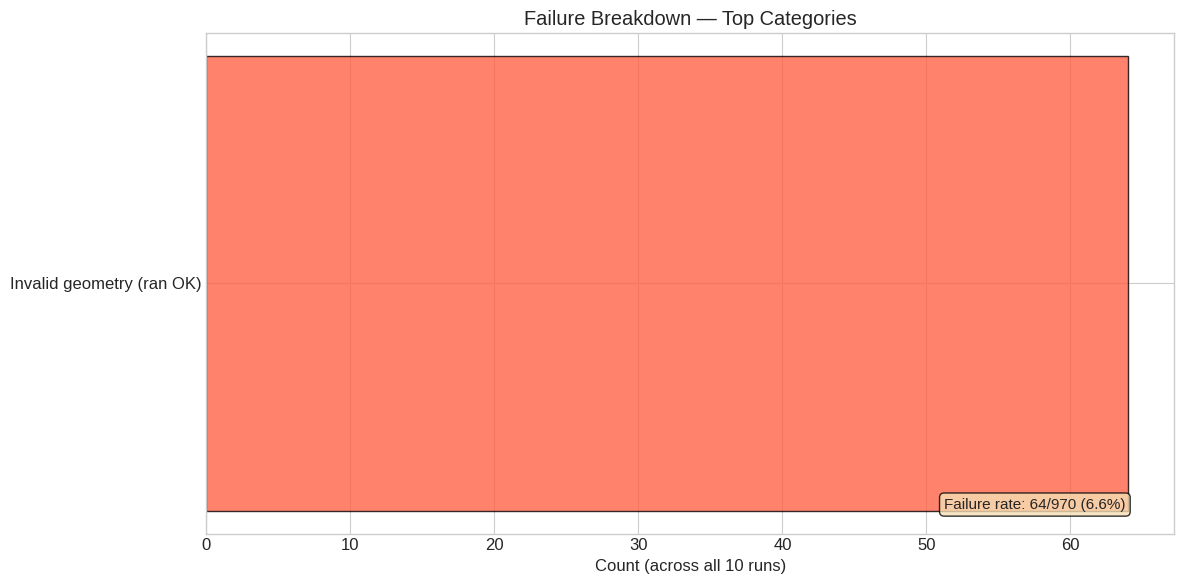

In [111]:
# Count all failure modes: explicit errors + zero-score evaluations
all_errors = []
for data in runs.values():
    # Explicit errors from log
    all_errors.extend(data['errors'])
    # Also count zero-score programs without explicit errors as "evaluation failures"
    for it in data['iterations']:
        if it.get('combined_score', -1) == 0.0 and it.get('validity', -1) == 0.0:
            all_errors.append('Evaluation failure (invalid geometry)')

# Categorize errors
error_categories = defaultdict(int)
for err in all_errors:
    err_clean = err.replace('Program execution failed: ', '')
    if 'run_packing' in err_clean:
        error_categories['Missing run_packing()'] += 1
    elif 'scipy' in err_clean or 'ModuleNotFoundError' in err_clean:
        error_categories['Module import error'] += 1
    elif 'index' in err_clean and 'out of bounds' in err_clean:
        error_categories['Index out of bounds'] += 1
    elif 'SyntaxError' in err_clean or 'invalid syntax' in err_clean:
        error_categories['Syntax error'] += 1
    elif 'not defined' in err_clean:
        error_categories['Undefined variable'] += 1
    elif 'broadcast' in err_clean or 'shape' in err_clean:
        error_categories['Shape mismatch'] += 1
    elif 'timeout' in err_clean:
        error_categories['Timeout'] += 1
    elif 'Invalid shapes' in err_clean:
        error_categories['Invalid shapes'] += 1
    elif 'not enough values' in err_clean:
        error_categories['Wrong return signature'] += 1
    elif 'invalid geometry' in err_clean:
        error_categories['Invalid geometry (ran OK)'] += 1
    elif err_clean.startswith('0.0000'):
        error_categories['Zero score (other)'] += 1
    else:
        error_categories[err_clean[:50]] += 1

if error_categories:
    fig, ax = plt.subplots(figsize=(12, 6))
    sorted_errors = sorted(error_categories.items(), key=lambda x: x[1], reverse=True)
    labels, counts = zip(*sorted_errors[:10])
    ax.barh(range(len(labels)), counts, color='tomato', alpha=0.8, edgecolor='black')
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_xlabel(f'Count (across all {NUM_RUNS} runs)')
    ax.set_title('Failure Breakdown — Top Categories')
    ax.invert_yaxis()
    
    total_iters = sum(len(d['iterations']) for d in runs.values())
    total_errors = sum(counts)
    ax.text(0.95, 0.05, f'Failure rate: {total_errors}/{total_iters} ({100*total_errors/max(total_iters,1):.1f}%)',
            transform=ax.transAxes, ha='right', fontsize=11, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('baseline_errors.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No failures found across all runs!')

### 5b. Detailed Error Deep Dive
Re-parse logs directly to catch ALL failure modes including timeouts, invalid shapes from evaluation lines, and errors on Metrics lines that the basic parser misses.

Total iterations: 970
Total failures:   344 (35.5%)
Valid rate:        64.5%

   201  ( 20.7% of iters)  Timeout / Zero score
    48  (  4.9% of iters)  Shape/broadcast mismatch
    26  (  2.7% of iters)  Other runtime error
    21  (  2.2% of iters)  Invalid shapes (wrong n)
    20  (  2.1% of iters)  Type error
    12  (  1.2% of iters)  Index out of bounds
     6  (  0.6% of iters)  Invalid geometry
     4  (  0.4% of iters)  Wrong return signature
     4  (  0.4% of iters)  Syntax error
     2  (  0.2% of iters)  Undefined variable


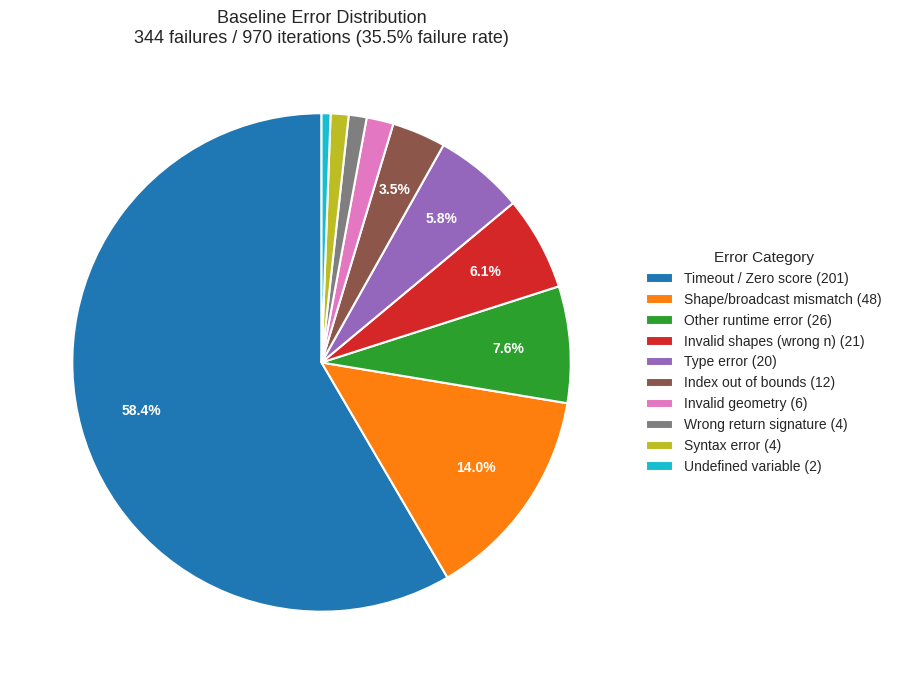


Per-run breakdown:
  Run 1: 27 failures / 100 iters (27%)
     16  Timeout / Zero score
      2  Shape/broadcast mismatch
      2  Invalid shapes (wrong n)
      2  Index out of bounds
      1  Invalid geometry
      4  Wrong return signature
  Run 2: 17 failures / 100 iters (17%)
      8  Timeout / Zero score
      6  Other runtime error
      1  Invalid shapes (wrong n)
      2  Index out of bounds
  Run 3: 26 failures / 100 iters (26%)
      8  Timeout / Zero score
     10  Shape/broadcast mismatch
      1  Invalid shapes (wrong n)
      6  Index out of bounds
      1  Invalid geometry
  Run 4: 23 failures / 100 iters (23%)
      6  Timeout / Zero score
      2  Shape/broadcast mismatch
      4  Other runtime error
      2  Invalid shapes (wrong n)
      8  Type error
      1  Invalid geometry
  Run 5: 27 failures / 100 iters (27%)
      4  Timeout / Zero score
     10  Shape/broadcast mismatch
      8  Other runtime error
      1  Invalid shapes (wrong n)
      2  Type error
     

In [119]:
def parse_errors_detailed(log_path):
    """Parse ALL failure modes from a log, including timeouts and Metrics-line errors."""
    errors = []
    with open(log_path) as f:
        for line in f:
            if 'error=' in line and ('Iteration' in line or 'Metrics' in line):
                err_match = re.search(r'error=(.+?)(?:,|$)', line)
                if err_match:
                    errors.append(err_match.group(1).strip())
            elif 'timeout=1.0000' in line:
                errors.append('Timeout (>90s)')
            elif 'Evaluated program' in line and 'combined_score=0.0000' in line:
                if 'error=' in line:
                    err_match = re.search(r'error=(.+?)(?:,|$)', line)
                    if err_match:
                        errors.append(err_match.group(1).strip())
                elif 'Invalid shapes' in line:
                    errors.append('Invalid shapes')
                elif 'validity=0.0000' in line:
                    errors.append('Invalid geometry (score=0)')
    return errors

def categorize_error(err):
    """Map raw error string to a human-readable category."""
    e = err.replace('Program execution failed: ', '')
    if 'timeout' in e.lower() or e.startswith('0.0000'):
        return 'Timeout / Zero score'
    elif 'Invalid shapes' in e:
        return 'Invalid shapes (wrong n)'
    elif 'Invalid geometry' in e:
        return 'Invalid geometry'
    elif 'run_packing' in e:
        return 'Missing run_packing()'
    elif 'not defined' in e:
        return 'Undefined variable'
    elif 'index' in e and 'out of bounds' in e:
        return 'Index out of bounds'
    elif 'broadcast' in e or ('shape' in e and 'Invalid' not in e):
        return 'Shape/broadcast mismatch'
    elif 'not enough values' in e:
        return 'Wrong return signature'
    elif 'syntax' in e.lower() or 'invalid character' in e:
        return 'Syntax error'
    elif 'unsupported operand' in e or 'not callable' in e or 'has no' in e:
        return 'Type error'
    else:
        return 'Other runtime error'

# Re-parse all logs with detailed error extraction
per_run_errors = {}
per_run_categories = {}
for i in sorted(runs.keys()):
    log_files = sorted(glob.glob(str(BASE_DIR / f'run_{i}' / 'logs' / '*.log')))
    if log_files:
        raw_errors = parse_errors_detailed(log_files[-1])
        per_run_errors[i] = raw_errors
        cats = defaultdict(int)
        for e in raw_errors:
            cats[categorize_error(e)] += 1
        per_run_categories[i] = dict(cats)

# Aggregate across all runs
agg_categories = defaultdict(int)
for cats in per_run_categories.values():
    for cat, count in cats.items():
        agg_categories[cat] += count

total_iters = sum(len(d['iterations']) for d in runs.values())
total_failures = sum(agg_categories.values())
print(f"Total iterations: {total_iters}")
print(f"Total failures:   {total_failures} ({100*total_failures/total_iters:.1f}%)")
print(f"Valid rate:        {100*(total_iters-total_failures)/total_iters:.1f}%\n")

for cat, count in sorted(agg_categories.items(), key=lambda x: -x[1]):
    print(f"  {count:4d}  ({100*count/total_iters:5.1f}% of iters)  {cat}")

# --- Pie chart with separate legend, using tab10 for distinct colors ---
sorted_cats = sorted(agg_categories.items(), key=lambda x: -x[1])
labels = [cat for cat, _ in sorted_cats]
sizes = [count for _, count in sorted_cats]
pie_colors = plt.cm.tab10(np.arange(len(labels)))

fig, ax = plt.subplots(figsize=(10, 7))

wedges, texts, autotexts = ax.pie(
    sizes,
    colors=pie_colors,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',
    pctdistance=0.75,
    startangle=90,
    textprops={'fontsize': 10, 'color': 'white', 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
for t in texts:
    t.set_text('')

legend_labels = [f"{lab} ({cnt})" for lab, cnt in sorted_cats]
ax.legend(wedges, legend_labels, title="Error Category",
          loc="center left", bbox_to_anchor=(1.0, 0.5),
          fontsize=10, title_fontsize=11)

ax.set_title(
    f'Baseline Error Distribution\n'
    f'{total_failures} failures / {total_iters} iterations '
    f'({100*total_failures/total_iters:.1f}% failure rate)',
    fontsize=13,
)

plt.tight_layout()
plt.savefig('baseline_error_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-run breakdown
print("\nPer-run breakdown:")
all_cats = sorted(agg_categories.keys(), key=lambda c: -agg_categories[c])
for r in sorted(per_run_categories.keys()):
    cats = per_run_categories.get(r, {})
    total = sum(cats.values())
    n_iters = len(runs[r]['iterations'])
    print(f"  Run {r}: {total} failures / {n_iters} iters ({100*total/max(n_iters,1):.0f}%)")
    for cat in all_cats:
        c = cats.get(cat, 0)
        if c > 0:
            print(f"    {c:3d}  {cat}")

### 5c. v0.2 Error Distribution (300s timeout)
Same analysis for the v0.2 baseline which uses a 300s timeout instead of 90s.

v0.2 (+T300): 855 iterations, 168 failures (19.6%)

    49  (  5.7% of iters)  Timeout / Zero score
    32  (  3.7% of iters)  Invalid geometry
    23  (  2.7% of iters)  Invalid shapes (wrong n)
    22  (  2.6% of iters)  Shape/broadcast mismatch
    20  (  2.3% of iters)  Index out of bounds
    12  (  1.4% of iters)  Other runtime error
     8  (  0.9% of iters)  Type error
     2  (  0.2% of iters)  Undefined variable


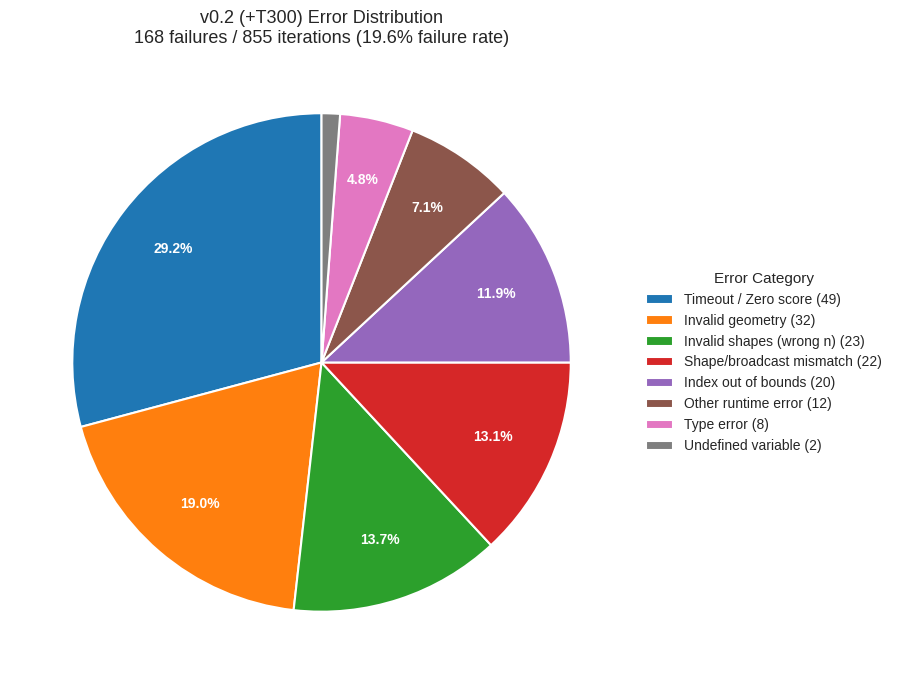

In [120]:
# v0.2 error analysis (300s timeout baseline)
V02_DIR = Path('baseline_v02_runs')
V02_RUNS = 10

v02_per_run_categories = {}
for i in range(1, V02_RUNS + 1):
    log_files = sorted(glob.glob(str(V02_DIR / f'run_{i}' / 'logs' / '*.log')))
    if log_files:
        raw_errors = parse_errors_detailed(log_files[-1])
        cats = defaultdict(int)
        for e in raw_errors:
            cats[categorize_error(e)] += 1
        v02_per_run_categories[i] = dict(cats)

v02_agg = defaultdict(int)
v02_total_iters = 0
for i, cats in v02_per_run_categories.items():
    for cat, count in cats.items():
        v02_agg[cat] += count
    # Count iterations from logs
    log_files = sorted(glob.glob(str(V02_DIR / f'run_{i}' / 'logs' / '*.log')))
    if log_files:
        with open(log_files[-1]) as f:
            v02_total_iters += sum(1 for line in f if 'Iteration' in line and 'completed' in line)

v02_total_failures = sum(v02_agg.values())
print(f"v0.2 (+T300): {v02_total_iters} iterations, {v02_total_failures} failures "
      f"({100*v02_total_failures/max(v02_total_iters,1):.1f}%)\n")

for cat, count in sorted(v02_agg.items(), key=lambda x: -x[1]):
    print(f"  {count:4d}  ({100*count/max(v02_total_iters,1):5.1f}% of iters)  {cat}")

# --- v0.2 Pie chart ---
sorted_cats_v02 = sorted(v02_agg.items(), key=lambda x: -x[1])
labels_v02 = [cat for cat, _ in sorted_cats_v02]
sizes_v02 = [count for _, count in sorted_cats_v02]
pie_colors_v02 = plt.cm.tab10(np.arange(len(labels_v02)))

fig, ax = plt.subplots(figsize=(10, 7))

wedges, texts, autotexts = ax.pie(
    sizes_v02,
    colors=pie_colors_v02,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',
    pctdistance=0.75,
    startangle=90,
    textprops={'fontsize': 10, 'color': 'white', 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
for t in texts:
    t.set_text('')

legend_labels = [f"{lab} ({cnt})" for lab, cnt in sorted_cats_v02]
ax.legend(wedges, legend_labels, title="Error Category",
          loc="center left", bbox_to_anchor=(1.0, 0.5),
          fontsize=10, title_fontsize=11)

ax.set_title(
    f'v0.2 (+T300) Error Distribution\n'
    f'{v02_total_failures} failures / {v02_total_iters} iterations '
    f'({100*v02_total_failures/max(v02_total_iters,1):.1f}% failure rate)',
    fontsize=13,
)

plt.tight_layout()
plt.savefig('v02_error_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()

### 5d. v0 vs v0.2 Error Comparison
Side-by-side grouped bar chart showing how the 300s timeout changes the error profile.

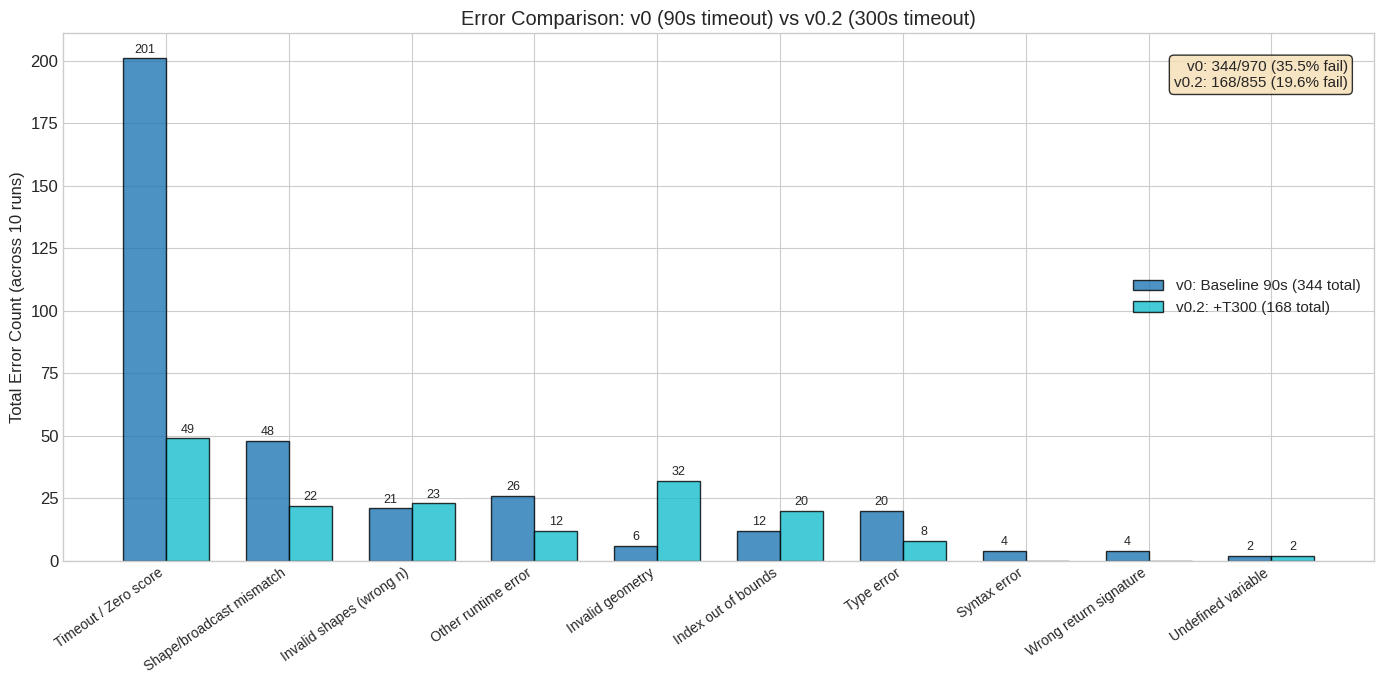

In [121]:
# Grouped bar chart: v0 vs v0.2 error counts by category
# Use consistent category ordering from the union of both
all_cats_union = sorted(
    set(list(agg_categories.keys()) + list(v02_agg.keys())),
    key=lambda c: -(agg_categories.get(c, 0) + v02_agg.get(c, 0))
)

v0_counts = [agg_categories.get(cat, 0) for cat in all_cats_union]
v02_counts = [v02_agg.get(cat, 0) for cat in all_cats_union]

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(all_cats_union))
bar_width = 0.35

bars1 = ax.bar(x - bar_width/2, v0_counts, bar_width, label=f'v0: Baseline 90s ({total_failures} total)',
               color='#1f77b4', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + bar_width/2, v02_counts, bar_width, label=f'v0.2: +T300 ({v02_total_failures} total)',
               color='#17becf', alpha=0.8, edgecolor='black')

# Add count labels on bars
for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, str(int(h)),
                ha='center', va='bottom', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, str(int(h)),
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(all_cats_union, rotation=35, ha='right', fontsize=10)
ax.set_ylabel('Total Error Count (across 10 runs)')
ax.set_title('Error Comparison: v0 (90s timeout) vs v0.2 (300s timeout)')
ax.legend(fontsize=11)

# Add failure rate annotation
ax.text(0.98, 0.95,
        f'v0: {total_failures}/{total_iters} ({100*total_failures/total_iters:.1f}% fail)\n'
        f'v0.2: {v02_total_failures}/{v02_total_iters} ({100*v02_total_failures/max(v02_total_iters,1):.1f}% fail)',
        transform=ax.transAxes, ha='right', va='top', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('v0_vs_v02_errors.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluation Time Distribution

/tmp/ipykernel_14243/2164257701.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


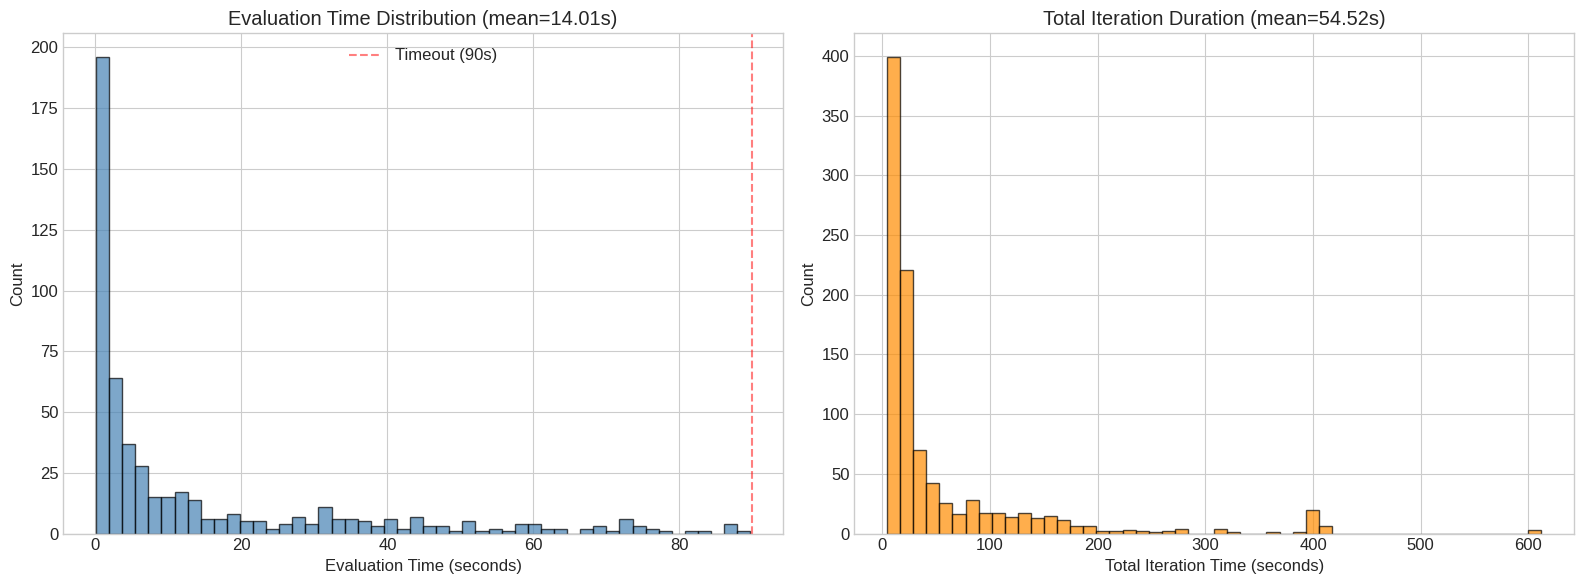

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Eval time distribution
eval_times = []
iter_durations = []
for data in runs.values():
    for it in data['iterations']:
        if 'eval_time' in it and it['eval_time'] > 0:
            eval_times.append(it['eval_time'])
        if 'duration' in it:
            iter_durations.append(it['duration'])

if eval_times:
    axes[0].hist(eval_times, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_xlabel('Evaluation Time (seconds)')
    axes[0].set_ylabel('Count')
    axes[0].set_title(f'Evaluation Time Distribution (mean={np.mean(eval_times):.2f}s)')
    axes[0].axvline(x=90, color='red', linestyle='--', alpha=0.5, label='Timeout (90s)')
    axes[0].legend()

if iter_durations:
    axes[1].hist(iter_durations, bins=50, edgecolor='black', alpha=0.7, color='darkorange')
    axes[1].set_xlabel('Total Iteration Time (seconds)')
    axes[1].set_ylabel('Count')
    axes[1].set_title(f'Total Iteration Duration (mean={np.mean(iter_durations):.2f}s)')
    axes[1].legend()

plt.tight_layout()
# plt.savefig('baseline_timing.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary Statistics

In [118]:
print('=' * 70)
print(f'BASELINE SUMMARY — GPT-5.4-mini × {NUM_RUNS} seeds × 100 iterations')
print('=' * 70)

final_scores = []
final_sum_radii = []
improvement_counts = []
valid_rates = []

for run_id in sorted(runs.keys()):
    data = runs[run_id]
    
    # Get best score from iterations
    best_score = max((it.get('combined_score', 0) for it in data['iterations']), default=0)
    best_sr = max((it.get('sum_radii', 0) for it in data['iterations'] 
                   if it.get('validity', 0) > 0), default=0)
    n_improvements = len(data['best_events'])
    n_valid = sum(1 for it in data['iterations'] if it.get('combined_score', 0) > 0)
    n_total = len(data['iterations'])
    valid_rate = n_valid / max(n_total, 1)
    
    final_scores.append(best_score)
    final_sum_radii.append(best_sr)
    improvement_counts.append(n_improvements)
    valid_rates.append(valid_rate)
    
    print(f'\nRun {run_id} (seed={run_id}):')
    print(f'  Best score:    {best_score:.4f} ({best_score*100:.1f}% of target)')
    print(f'  Sum radii:     {best_sr:.4f} / {TARGET}')
    print(f'  Improvements:  {n_improvements}')
    print(f'  Valid rate:    {n_valid}/{n_total} ({valid_rate*100:.1f}%)')
    print(f'  Errors:        {len(data["errors"])}')

print('\n' + '-' * 70)
print(f'AGGREGATE (n={len(runs)}):')
print(f'  Best score:    {np.mean(final_scores):.4f} +/- {np.std(final_scores):.4f}')
print(f'  Sum radii:     {np.mean(final_sum_radii):.4f} +/- {np.std(final_sum_radii):.4f}')
print(f'  Improvements:  {np.mean(improvement_counts):.1f} +/- {np.std(improvement_counts):.1f}')
print(f'  Valid rate:    {np.mean(valid_rates)*100:.1f}% +/- {np.std(valid_rates)*100:.1f}%')
print(f'  Target ratio:  {np.mean(final_sum_radii)/TARGET*100:.1f}%')

BASELINE SUMMARY — GPT-5.4-mini × 10 seeds × 100 iterations

Run 1 (seed=1):
  Best score:    0.8820 (88.2% of target)
  Sum radii:     2.3240 / 2.635
  Improvements:  16
  Valid rate:    70/100 (70.0%)
  Errors:        0

Run 2 (seed=2):
  Best score:    0.9299 (93.0% of target)
  Sum radii:     2.4503 / 2.635
  Improvements:  7
  Valid rate:    89/100 (89.0%)
  Errors:        0

Run 3 (seed=3):
  Best score:    0.8630 (86.3% of target)
  Sum radii:     2.2740 / 2.635
  Improvements:  10
  Valid rate:    85/100 (85.0%)
  Errors:        0

Run 4 (seed=4):
  Best score:    0.8775 (87.8% of target)
  Sum radii:     2.3122 / 2.635
  Improvements:  19
  Valid rate:    86/100 (86.0%)
  Errors:        0

Run 5 (seed=5):
  Best score:    0.7797 (78.0% of target)
  Sum radii:     2.0545 / 2.635
  Improvements:  10
  Valid rate:    84/100 (84.0%)
  Errors:        0

Run 6 (seed=6):
  Best score:    0.8658 (86.6% of target)
  Sum radii:     2.2813 / 2.635
  Improvements:  8
  Valid rate:    44/7

## 8. Best Program Details

In [110]:
# Load best program info from each run
for i in sorted(runs.keys()):
    info_path = BASE_DIR / f'run_{i}' / 'best' / 'best_program_info.json'
    if info_path.exists():
        with open(info_path) as f:
            info = json.load(f)
        print(f'Run {i}: iteration={info.get("iteration")}, '
              f'generation={info.get("generation")}, '
              f'sum_radii={info["metrics"].get("sum_radii", 0):.4f}, '
              f'eval_time={info["metrics"].get("eval_time", 0):.2f}s')
    else:
        print(f'Run {i}: no best_program_info.json found')

Run 1: iteration=88, generation=4, sum_radii=2.3240, eval_time=87.16s
Run 2: iteration=12, generation=3, sum_radii=2.4503, eval_time=0.21s
Run 3: iteration=86, generation=3, sum_radii=2.2740, eval_time=78.11s
Run 4: iteration=23, generation=4, sum_radii=2.3122, eval_time=33.29s
Run 5: iteration=33, generation=2, sum_radii=2.0545, eval_time=3.32s
Run 6: no best_program_info.json found
Run 7: iteration=89, generation=4, sum_radii=2.2200, eval_time=2.95s
Run 8: iteration=21, generation=3, sum_radii=2.5044, eval_time=61.92s
Run 9: no best_program_info.json found
Run 10: iteration=91, generation=2, sum_radii=2.3448, eval_time=30.30s
